# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**: Madeline Allen

**ID**: MCA76

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Note to Gaby:
Just FYI - I tried to summarize key points for each problem at the end of each problem! :) Also noticed some veryyyy different results for the first two problems depending on what minimization method I selected, explained somewhat below but just wanted to preface all results with that disclaimer haha!

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Environment

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

**NOTE: Used ChatGPT (openai, 2025) to convert all the Juila code blocks in the original HW5 version to Python.**

In [1]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure
import numpy as np  # for more efficient data manipulation (equivalent to DataFramesMeta)
import csv  # reads/writes .csv files
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # some additional statistical plotting tools
import datetime  # working with dates and times
from datetime import timedelta
import matplotlib.dates as mdates
import statsmodels.api as sm

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?

**NOTE - use of ChatGPT (OpenAI, 2025) in this quesiton:** I used chatgpt to convert the original Julia code listed in this quesiton to python, then had chatgpt make modifications to the way it parsed the dates and plotted it since originally labels were overlapping. I used ChatGPT to convert some of the code from the Modeling Extreme Values lecture slides from Julia to Python; all subsequent updates to that code were done by me, not ChatGPT.

In [2]:
# ithaca_dat = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
# plot(ithaca_dat.Day, ithaca_dat.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)

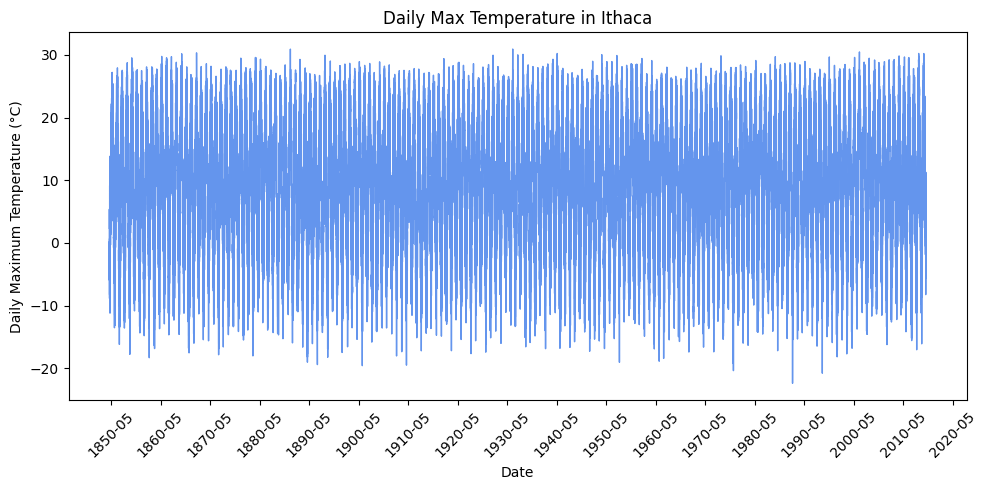

In [3]:
# Read the CSV and parse the 'Day' column as datetime
ithaca_dat = pd.read_csv("data/gfdl-esm4-tempmax-ithaca.csv")
ithaca_dat["Day"] = pd.to_datetime(ithaca_dat["Day"])

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(ithaca_dat["Day"], ithaca_dat["TempMax"], linewidth=1, color = 'cornflowerblue')
plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca")

# Format x-axis to show fewer, nicely spaced dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12*10))  # every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)  # rotate labels for readability
plt.tight_layout()
plt.show()

In [4]:
# isolate year
ithaca_dat['Year'] = ithaca_dat['Day'].dt.year #.dt.to_period('Y')  # yearmonth equivalent

# Find annual maxima
max_annual = ithaca_dat.loc[ithaca_dat.groupby('Year')['TempMax'].idxmax()]

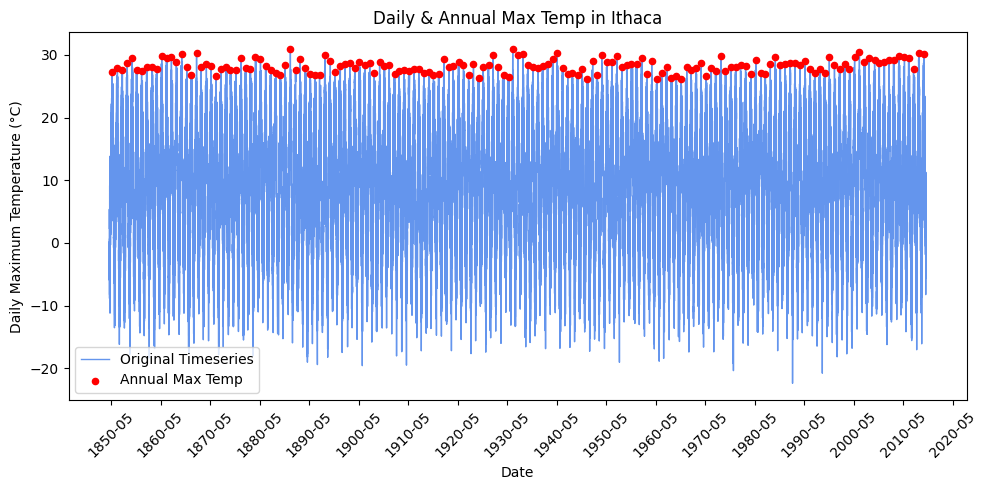

In [5]:
# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(ithaca_dat["Day"], ithaca_dat["TempMax"], linewidth=1, color = 'cornflowerblue', label='Original Timeseries')
# Plot the annual maxima
plt.scatter(max_annual['Day'], max_annual['TempMax'], color='red', label='Annual Max Temp', s=20, zorder=3)

plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily & Annual Max Temp in Ithaca")

# Format x-axis to show fewer, nicely spaced dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12*10))  # every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.legend()
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

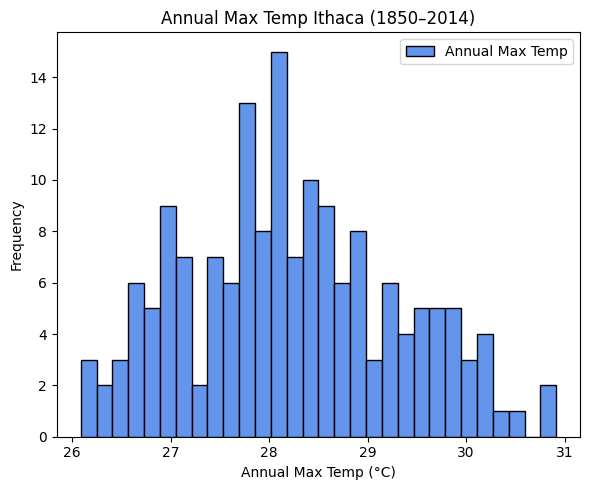

In [6]:
# Plot 
plt.figure(figsize=(6, 5))
plt.hist(max_annual['TempMax'], bins = 30, color = 'cornflowerblue', edgecolor='black', label = f'Annual Max Temp')
plt.xlabel("Annual Max Temp (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Annual Max Temp Ithaca (1850–2014)")
plt.tight_layout()
plt.show()

Stationary GEV parameters: shape (-ξ): 0.219, loc: 27.829, scale: 1.016


/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2318: RuntimeWarning: invalid value encountered in scalar subtract
  r = (xf - nfc) * (fx - ffulc)
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2319: RuntimeWarning: invalid value encountered in scalar subtract
  q = (xf - fulc) * (fx - fnfc)
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2320: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2321: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


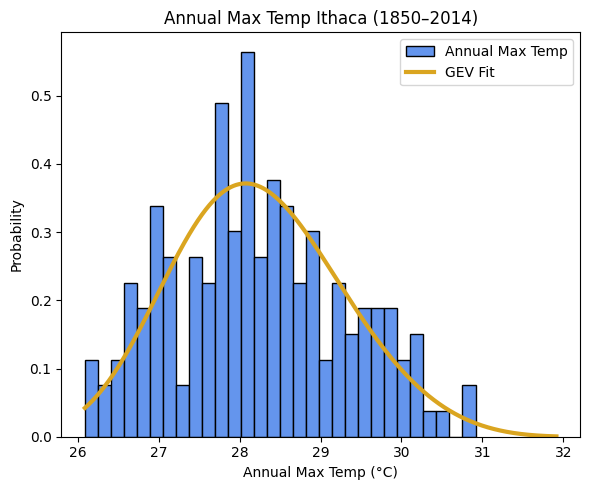

In [ ]:
# Fit a stationary GEV model to the annual maximum series and report your parameter estimates. 
from scipy.stats import genextreme
from scipy.optimize import minimize

# isolate max values
max_an_values = max_annual['TempMax'].values  

# Fit the GEV distribution using MLE
# SciPy uses a reversed sign convention for the shape parameter:
# Julia: ξ, SciPy: -ξ
#c, loc, scale = genextreme.fit(max_an_values)


# # ---- GEV Fit ----
def gev_nll(params):
    c, loc, scale = params
    if scale <= 0:
        return np.inf
    return -np.sum(genextreme.logpdf(max_an_values, c=c, loc=loc, scale=scale))

#note i had to give "good" initial estimates of loc and scale to get this to work properly
init_theta = [0, np.mean(max_an_values), np.std(max_an_values)]
bounds = [(-1.0, 1.0), (-100, 100), (1e-6, 100)]

# Optimize
result = minimize(gev_nll, init_theta, bounds=bounds, method="Powell")
log_lik_stat = -result.fun

theta_mle = result.x
c_hat, loc_hat, scale_hat = theta_mle

round_to = 3
print(f"Stationary GEV parameters: shape (-ξ): {round(c_hat,round_to)}, loc: {round(loc_hat,round_to)}, scale: {round(scale_hat,round_to)}")

# # # Example: PDF, log-likelihood, etc.
# log_lik = np.sum(genextreme.logpdf(max_an_values, c_hat, loc=loc_hat, scale=scale_hat))
# print("Log-likelihood:", log_lik)

# Plot 
plt.figure(figsize=(6, 5))
plt.hist(max_annual['TempMax'], bins = 30, color = 'cornflowerblue', edgecolor='black', label = f'Annual Max Temp', density=True)

# Evaluate GEV PDF
min_val = max_an_values.min()
max_val = max_an_values.max() + 1
x = np.linspace(min_val, max_val, 5000)
gev_pdf = genextreme.pdf(x, c_hat, loc=loc_hat, scale=scale_hat)
plt.plot(x, gev_pdf, linewidth=3, color='goldenrod', label="GEV Fit")
plt.xlabel("Annual Max Temp (°C)")
plt.ylabel("Probability")
plt.legend()
plt.title(fr"Annual Max Temp Ithaca (1850–2014)")
plt.tight_layout()
plt.show()

**See interpretation at end of question.**

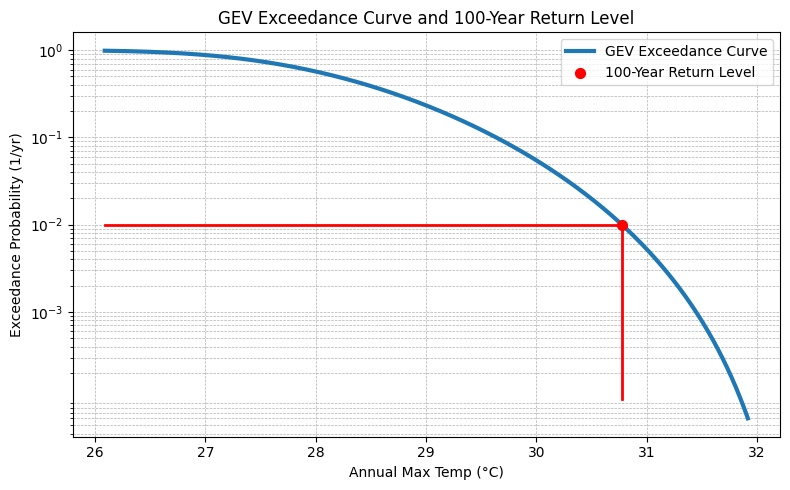

100 year return level: 30.775 °C


In [9]:
# GEV CDF function (SciPy convention)
def gevcdf(x):
    return genextreme.cdf(x, c_hat, loc=loc_hat, scale=scale_hat)

# 100-year return level (i.e., quantile at 0.99)
rl_100 = genextreme.ppf(0.99, c_hat, loc=loc_hat, scale=scale_hat)

# Exceedance probabilities
x_vals = np.arange(min_val, max_val + 0.01, 0.01)
exceedance_probs = 1 - gevcdf(x_vals)

# Plot exceedance curve
plt.figure(figsize=(8, 5))
plt.plot(x_vals, exceedance_probs, lw=3, label='GEV Exceedance Curve')


# Add horizontal line at 0.01 and vertical line at the 100-year return level
# Horizontal line at y=0.01 (red)
plt.plot(np.arange(np.min(x_vals), rl_100, 0.01), [0.01]*len(np.arange(np.min(x_vals), rl_100, 0.01)), color='red', lw=2)
# Vertical line at rl_100 (red) with logarithmic scale for y-axis
plt.plot([rl_100]*len(np.arange(-4, -2 + 0.01, 0.01)), 10**np.arange(-4.0, -2.0 + 0.01, 0.01), color='red', lw=2)
# Scatter plot the return level
plt.scatter([rl_100], [0.01], color='red', s=50, zorder=5, label='100-Year Return Level')
# Axis scaling and labels
plt.yscale('log')
plt.yticks(10.0**np.arange(-3.0, 0.1, 1.0), labels=[f"$10^{{{int(e)}}}$" for e in np.arange(-3, 1)])
plt.xlabel("Annual Max Temp (°C)")
plt.ylabel("Exceedance Probability (1/yr)")
plt.title("GEV Exceedance Curve and 100-Year Return Level")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

print(f'100 year return level: {round(rl_100,round_to)} °C')


**See interpretation at end of question.**

### Nonstationary:

Only the location parameter is non-stationary, and $t=0$ corresponds to 1850.
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$

In [10]:
# Now fit a nonstationary GEV with respect to time 
# (only the location parameter should be non-stationary),$y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling purposes, begin with $t=0$ corresponding to 1850).

t0 = 1850
max_annual["t"] = max_annual["Year"] - t0

def gev_nll_nonstationary(params):
    c, loc_0, loc_1, scale = params
    #make location param nonstationary:
    loc = loc_0+loc_1*max_annual['t']
    # max_annual['Day'].values  
    if scale <= 0:
        return np.inf
    return -np.sum(genextreme.logpdf(max_an_values, c=c, loc=loc, scale=scale))

#note i had to give "good" initial estimates of loc and scale to get this to work properly
init_theta_nonstat = [0, np.mean(max_an_values), 0.1, np.std(max_an_values)]
bounds = [(-1.0, 1.0), (-100, 100), (-50, 50), (1e-6, 100)]


# Optimize
result_nonstat = minimize(gev_nll_nonstationary, init_theta_nonstat, bounds=bounds, method="Powell")
log_lik_nonstat = -result_nonstat.fun

theta_mle_nonstat = result_nonstat.x
c_hat_nonstat, loc_0_hat_nonstat, loc_1_hat_nonstat, scale_hat_nonstat = theta_mle_nonstat

round_to = 3
print(f"GEV parameters for nonstationary: shape (-ξ): {round(c_hat_nonstat,round_to)}, loc_0: {round(loc_0_hat_nonstat,round_to)}, loc_1: {round(loc_1_hat_nonstat,round_to)}, scale: {round(scale_hat_nonstat,round_to)}")


GEV parameters for nonstationary: shape (-ξ): 0.219, loc_0: 27.661, loc_1: 0.002, scale: 1.016


/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2320: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2321: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2318: RuntimeWarning: invalid value encountered in scalar subtract
  r = (xf - nfc) * (fx - ffulc)
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2319: RuntimeWarning: invalid value encountered in scalar subtract
  q = (xf - fulc) * (fx - fnfc)
/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/o

In [32]:
# What are the AIC values for each model? What can you conclude about the relative evidence for non-stationarity?
# AIC = 2 * (number of parameters) - 2 * (log-likelihood) 
AIC_stationary = 3 - 2 * log_lik_stat
AIC_nonstationary = 4 - 2 * log_lik_nonstat
print(f'The AIC values for the two models are: stationary: {round(AIC_stationary,3)}; nonstationary: {round(AIC_nonstationary,3)}')

The AIC values for the two models are: stationary: 489.931; nonstationary: 489.595


#### Problem 1 Commentary:

In problem 1 above, I fit a stationary GEV model, and then fit a nonstationary GEV model (allowing the location parameter to vary with time); the fitted models are plotted above along with the data. Note that I realized the resulting parameter estimates for both models were VERY sensitive to 1) the optimization method selected, and 2) the initial parameter estimates; I discussed this with Vivek and adjusted my approach to make sure I was using a bounded optimization (to help explore full param space instead of only locally, which can happen with unbounded optimization). 

**Stationary GEV:**

- Stationary GEV parameters: shape (-ξ): 0.219, loc: 27.829, scale: 1.016
- The shape parameter used in this package represents -ξ, so ξ here is actually -0.219. A negative ξ parameter means that the GEV "type" is Weibull (aka bounded). This can be the result of either 1) not having many extremes in the existing dataset (and thus having the bounded version of the GEV result in the best fit), and/or 2) air temperature actually being bounded (and we know that in terms of thermodynamics, there is definitely an upper bound on what the air temperature can be; I didn't try to figure out if the extreme values in this dataset are in fact near that upper bound, but if I were doing an actual project with this analysis, that would be the next thing I would check).
- The 100-year return level is 30.775 °C.


**Nonstationary GEV:**

- GEV parameters for nonstationary: shape (-ξ): 0.219, loc_0: 27.661, loc_1: 0.002, scale: 1.016


**Comparison based on AIC:**
- The AIC values for the two models are: stationary: 489.931; nonstationary: 489.595. As these are incredibly close, I would conclude that there is insufficient evidence (shown here) that would suggest that the daily max temp should or should not be represented in a nonstationary way (i.e., both of these models could be plausible, and to fully explore the uncertainty in estiamtes of air temperature extremes, both models should be used in further analysis.)

### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/719788578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceedances['Year'] = exceedances['Day'].dt.year
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/719788578.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceedances['event_count_nocluster'] = exceedances.groupby('Year')['Year'].transform('count')


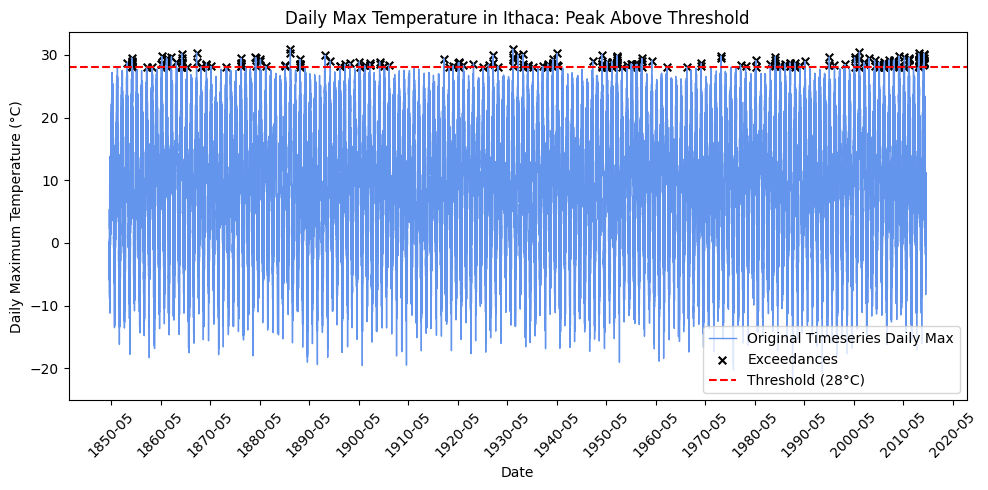

In [12]:
# threshold of interest:
thresh = 28
# isolate temperature exceedances over 28°C
exceedances = ithaca_dat[ithaca_dat['TempMax'] > thresh]
exceedances['Year'] = exceedances['Day'].dt.year
exceedances['event_count_nocluster'] = exceedances.groupby('Year')['Year'].transform('count')

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(ithaca_dat["Day"], ithaca_dat["TempMax"], linewidth=1, color = 'cornflowerblue', label='Original Timeseries Daily Max')
plt.scatter(exceedances['Day'], exceedances['TempMax'], color='black', marker='x', s=30, label="Exceedances")
plt.axhline(thresh, color='red', linestyle='--', label="Threshold (28°C)")
plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca: Peak Above Threshold")

# Format x-axis to show fewer, nicely spaced dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12*10))  # every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.legend()
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

### Decluster

In [41]:
# Total number of exceedances
N = len(exceedances)

# Calculate time differences between consecutive exceedances
T = np.diff(exceedances['Day'].values)  # Difference in datetime

# Convert time differences to days
T_days = T.astype('timedelta64[D]').astype(int)

# Extremal index formula
theta = 2 * np.sum(T_days)**2 / ((N - 1) * np.sum(T_days**2))

# Clustering duration (reciprocal of extremal index)
clust_dur = np.rint(1/theta).astype(int)

# Print the results
print(f"Total number of exceedances: {N}")
print(f"Extremal index (θ): {theta:.3}")
print(f"Clustering duration (1/θ; i.e., reciprocal of extremal index): {clust_dur} days")

Total number of exceedances: 231
Extremal index (θ): 0.478
Clustering duration (1/θ; i.e., reciprocal of extremal index): 2 days


In [42]:
# Define the clustering function
def assign_cluster(dat, period):
    clusters = np.zeros(len(dat), dtype=int)
    cluster_index = 1
    for i in range(len(dat)):
        if clusters[i] == 0:  # If the point hasn't been assigned a cluster
            # Find all indices where the time difference is less than or equal to the period
            # Ensure the result is in days
            time_diffs = np.abs(dat - dat[i])
            clusters[time_diffs <= period] = cluster_index
            cluster_index += 1
    return clusters

# Create a Timedelta from the clustering duration
period = pd.Timedelta(days=clust_dur)  # Period in days

# Ensure 'Day' is in datetime format (you should have already done this)
exceedances['Day'] = pd.to_datetime(exceedances['Day'])

# Apply the clustering function to the 'Day' column
exceedances['cluster'] = assign_cluster(exceedances['Day'].values, period)

# Check the result
print(f"Number of unique clusters: {exceedances['cluster'].nunique()}")


Number of unique clusters: 164


/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/3104043919.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceedances['Day'] = pd.to_datetime(exceedances['Day'])
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/3104043919.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceedances['cluster'] = assign_cluster(exceedances['Day'].values, period)


In [43]:
# Find maximum value within each cluster
exceedances_decluster = exceedances.loc[exceedances.groupby('cluster')['TempMax'].idxmax()]
#count per year
exceedances_decluster['event_count_decluster'] = exceedances_decluster.groupby('Year')['Year'].transform('count')


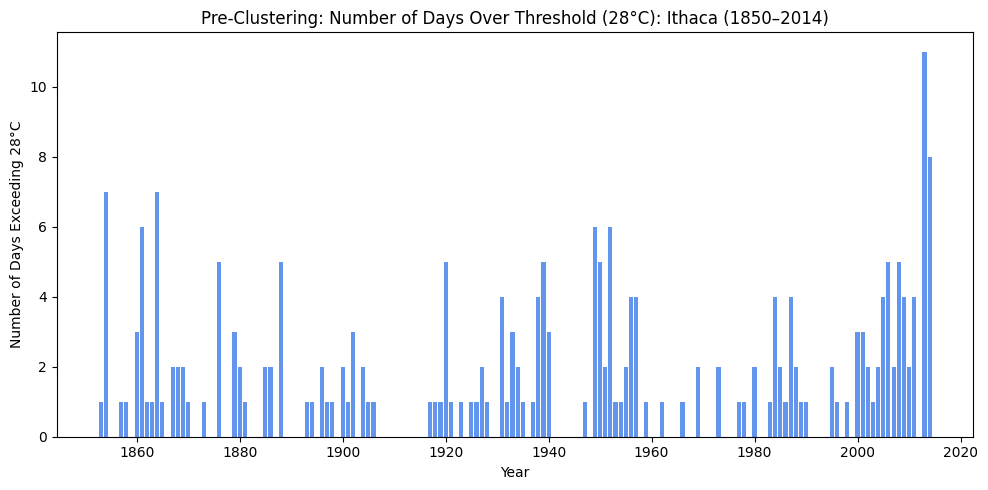

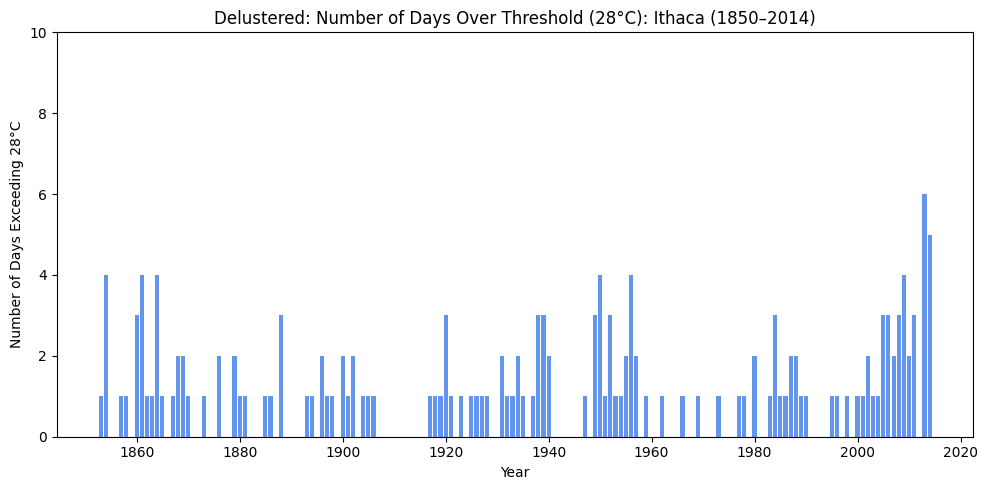

In [44]:
# show peak over threshold by year before clustering
plt.figure(figsize=(10, 5))
plt.bar(exceedances['Year'], exceedances['event_count_nocluster'], linewidth=1, color = 'cornflowerblue')
plt.xlabel("Year")
plt.ylabel("Number of Days Exceeding 28°C")
plt.title("Pre-Clustering: Number of Days Over Threshold (28°C): Ithaca (1850–2014)")
plt.tight_layout()
plt.show()

# Plot the data
plt.figure(figsize=(10, 5))
plt.bar(exceedances_decluster['Year'], exceedances_decluster['event_count_decluster'], linewidth=1, color = 'cornflowerblue')#
plt.xlabel("Year")
plt.ylabel("Number of Days Exceeding 28°C")
plt.title("Delustered: Number of Days Over Threshold (28°C): Ithaca (1850–2014)")
plt.ylim(0,10)
plt.tight_layout()
plt.show()

**See interpretation at end of question.**

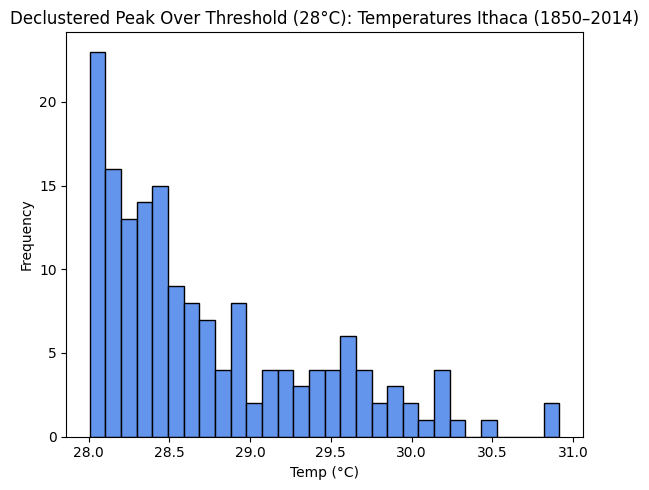

In [45]:
# Plot 
plt.figure(figsize=(6, 5))
plt.hist(exceedances_decluster['TempMax'], bins = 30, color = 'cornflowerblue', edgecolor='black', label = f'Declustered Peak Over Threshold')
plt.xlabel("Temp (°C)")
plt.ylabel("Frequency")
plt.title(fr"Declustered Peak Over Threshold (28°C): Temperatures Ithaca (1850–2014)")
plt.tight_layout()
plt.show()

**See interpretation at end of question.**

### Fit GPD:

GPD Parameter Estimates: shape: -0.197; loc: 0; scale: 0.903


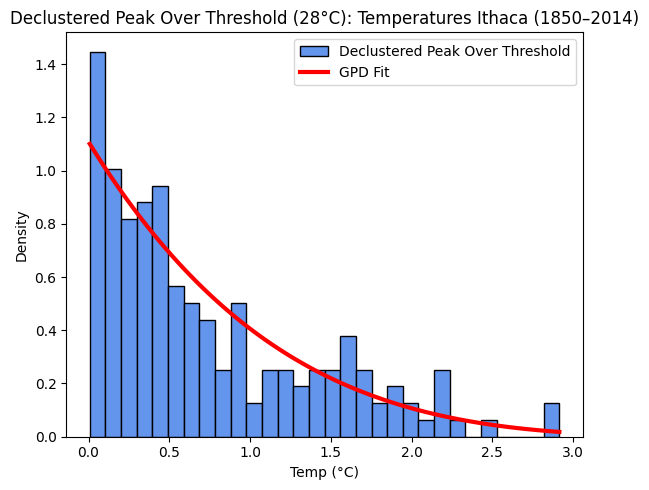

In [53]:
from scipy.stats import genpareto

# Fit the Generalized Pareto Distribution using the 'fit' method
# exceedance above threshold:
exceedance_above_thresh = exceedances_decluster['TempMax'] - thresh

shape, loc, scale = genpareto.fit(exceedance_above_thresh, floc=0)  # Fix location to 0 as in the original code

print(f'GPD Parameter Estimates: shape: {shape:.3}; loc: {loc}; scale: {scale:.3}')

# Create histogram with density=True
plt.figure(figsize=(6, 5))
plt.hist(exceedances_decluster['TempMax']- thresh, bins=30, color='cornflowerblue', edgecolor='black', 
         label=f'Declustered Peak Over Threshold', density=True)

# Plot GPD fit on top of histogram
x_vals = np.linspace(np.min(exceedance_above_thresh), np.max(exceedance_above_thresh), 100)
# x_vals = np.linspace(28,31,100)
y_vals = genpareto.pdf(x_vals, shape, loc, scale)

#Plot GPD fit (without scaling, since histogram is now normalized to density)
plt.plot(x_vals, y_vals, 'r-', lw=3, label="GPD Fit")

# Labels and Title
plt.xlabel("Temp (°C)")
plt.ylabel("Density")
plt.title(r"Declustered Peak Over Threshold (28°C): Temperatures Ithaca (1850–2014)")
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

Used chatgpt (2025) to help create count table below:

In [ ]:
# Define the full range of years to cover
full_year_range = pd.DataFrame({'Year': np.arange(ithaca_dat['Year'].min(),
                                                  ithaca_dat['Year'].max() + 1)})
# Compute the mean count per year (will exclude years with no data)
mean_counts = exceedances_decluster.groupby('Year', as_index=False)['event_count_decluster'].mean()
mean_counts.rename(columns={'event_count_decluster': 'count'}, inplace=True)

# Merge with full year range to fill missing years with NaNs
count_table = full_year_range.merge(mean_counts, on='Year', how='left')

# Fill missing values (NaN) with 0
count_table['count'].fillna(0, inplace=True)

/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/3642854212.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  count_table['count'].fillna(0, inplace=True)


The rate parameter of the poisson distribution (lambda) is 0.994


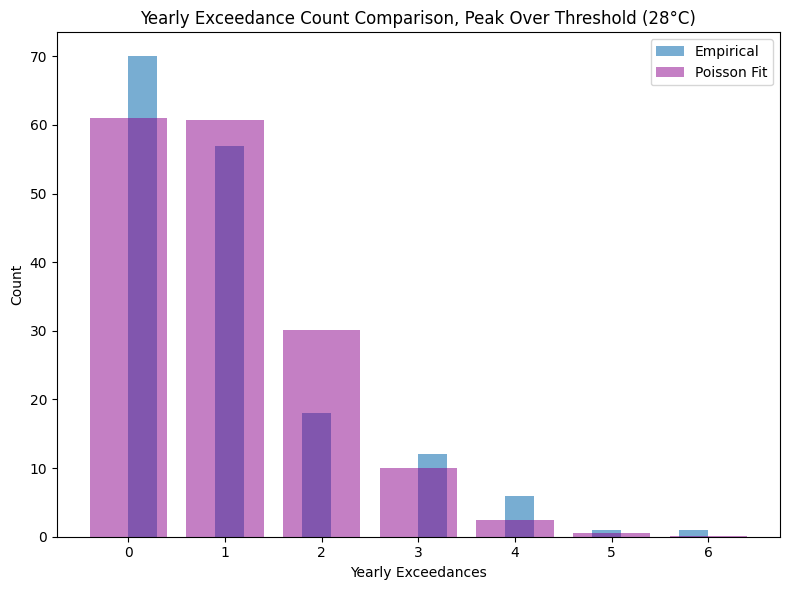

In [55]:
# MLE of lambda for poisson is just the mean
lmbda = np.mean(count_table['count'])
print(f'The rate parameter of the poisson distribution (lambda) is {lmbda:.3}')

# Plot histogram of yearly exceedances
plt.figure(figsize=(8, 6))
plt.hist(count_table['count'], bins=20, density=False, label="Empirical", alpha=0.6)
x_vals = np.arange(0, max(exceedances_decluster['event_count_decluster']) + 1)
#multiply pmf by number of years in dataset to get count of those years w that number of exceedances
plt.bar(x_vals, stats.poisson.pmf(x_vals, lmbda)*len(count_table), label="Poisson Fit", linewidth=1, alpha =0.5, color = 'darkmagenta')
plt.xlabel("Yearly Exceedances")
plt.ylabel("Count")
plt.legend()
plt.title("Yearly Exceedance Count Comparison, Peak Over Threshold (28°C)")
plt.tight_layout()
plt.show()



In [54]:
# calculate 100 year return level (from math on slides):
# RL_100 = 1 + (sigma / xi) * ((m * lambda)^xi - 1)
# note: mu = location, sigma = scale, shape = xi
# rewritten:
# RL_100 = 1 + (scale / shape) * ((m * lmbda)^shape - 1)
# i assume m is number of years in dataset??
m = 100 # 100 year return period
RL_100_threshold = thresh + (scale / shape) * ((m * lmbda)**shape - 1)

print(f'GPD-Poisson parameters: shape: {round(shape,round_to)}, loc: {round(loc,round_to)}, scale: {round(scale,round_to)}; and lambda = {round(lmbda,round_to)}')
print(f'100 year return level from peak over threshold estimation is : {round(RL_100_threshold,round_to)} °C')
print(f'Recall that 100 year return level from stationary block maxima is : {round(rl_100,round_to)} °C')

GPD-Poisson parameters: shape: -0.197, loc: 0, scale: 0.903; and lambda = 0.994
100 year return level from peak over threshold estimation is : 30.732 °C
Recall that 100 year return level from stationary block maxima is : 30.775 °C


#### Problem 2 Commentary:

- In problem 2 above, the peak-over-threshold (28°C) approach was used to examine air temp extremes. 
- The exceedances were declustered, and the number of exceedances by year were plotted. Visually just from the time series of number of exceedances over time, they somewhat appear to have increased over time, but it's difficult to say definitively - there are a couple years near the end of the time series that have larger numbers of exceedances than earlier in the timeseries, but if you got rid of those two years it would visually seem like there's relatively little change over time, so I would not feel comfortable strongly concluding that exceedances have increased over time. 
- A stationary Poisson-GPD model was fit to these exceedances, and the GPD distribution is plotted above along with the histogram of exceedances (visually looks similar to an exponential distribution; GPD appears to fit this data well).
- From my model, I estimate the 100-year return level to be 30.732 °C. Comparing this to the 100-year return level from the stationary GEV model in problem 1 (30.775 °C), we see that the two approaches to estimating the 100-year return level result in very similar temperature values. We would expect these two approaches to result in similar 100-year return levels as long as there is a sufficiently long data record, an appropriate block size is chosen for the block-maxima approach, and an appropriate threshold is selected for the peak-over-threshold approach. (If we had too short of a record, both methods would suffer; if too long a block was chosen and the GEV was being fit to only a couple maxima, this approach would suffer; if too high a threshold was chosen and the GPD-Poisson was being fit to only a few points, this approach would suffer; if too low a threshold was chosen and the GPD-Poisson was being fit to way too many points that didn't actually represent "extremes", then the resulting GPD would have a tail that was way fatter than appropriate for the data and inferences would be relatively nonsensicle). So - I'd conclude that we have a sufficiently long record and set the hyperparameters appropriately, and I am not surprised that they resulted in very similar 100-year return level estimates. (Honestly it's reassuring that they're so similar, before doing this exercise and thinking about it more deeply, I wasn't really sure what to expect).

### Problem 3

**This problem is only required for students in BEE 5850**.

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

**In this problem**:

-   Load and plot the deaths data. Linearly regress the number of deaths
    against time and report the coefficients for the fitted model. Add
    the regression line to your plot. What does this regression tell
    you?
-   Now linearly regress the deaths data against temperature. Once
    again, report the coefficients, and add the regression line to your
    plot. What does this regression tell you about the influence of
    temperature?
-   Expand your previous model by regressing deaths against temperature
    and PM2.5 density. Report the coefficients and add this regression
    line to your plot.
-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

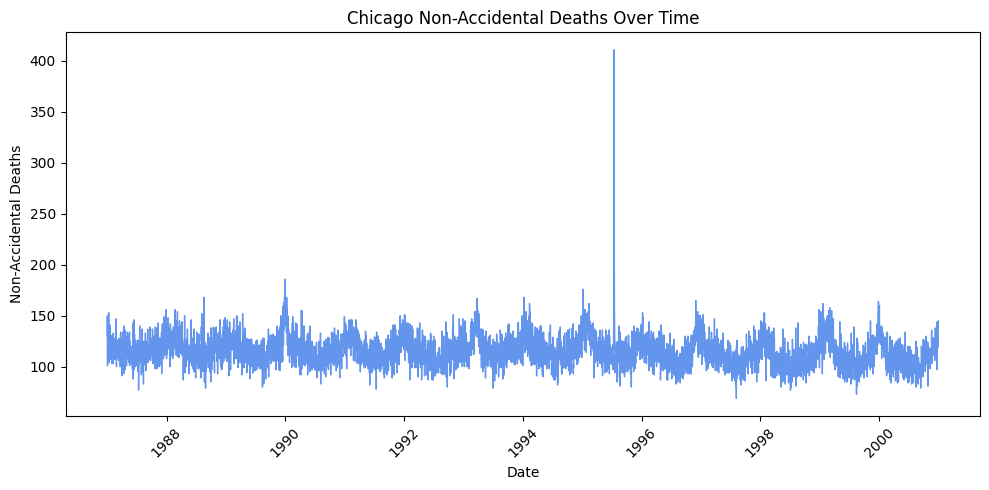

In [64]:
from datetime import datetime
# Read the CSV, treating "NA" as missing values
chicago_dat = pd.read_csv("data/chicago.csv", na_values="NA")

# Define the base date
day_zero = datetime.strptime("1993-12-31", "%Y-%m-%d")

# Compute dates by adding (time + 0.5) days to day_zero
chicago_dat["Date"] = chicago_dat["time"].apply(lambda t: day_zero + timedelta(days=t + 0.5))

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat["Date"], chicago_dat["death"], linewidth=1, color = 'cornflowerblue')
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


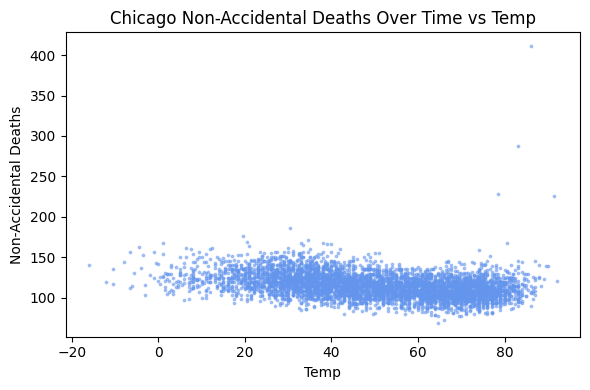

In [65]:
plt.figure(figsize=(6, 4))
plt.scatter(chicago_dat["tmpd"],chicago_dat["death"], color='cornflowerblue', alpha = 0.5, s = 3)
plt.xlabel("Temp")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time vs Temp")
plt.tight_layout()
plt.show()

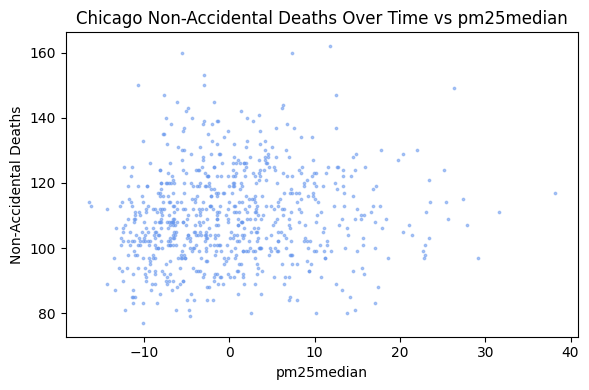

In [66]:
plt.figure(figsize=(6, 4))
plt.scatter(chicago_dat["pm25median"],chicago_dat["death"], color='cornflowerblue', alpha = 0.5, s = 3)
plt.xlabel("pm25median")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time vs pm25median")
plt.tight_layout()
plt.show()

### Regressed against time

Intercept: 115.419, time coefficient: -0.002, AIC: 42304.208


/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/1228376970.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int_time = model.params[0]
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/1228376970.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_time = model.params[1]


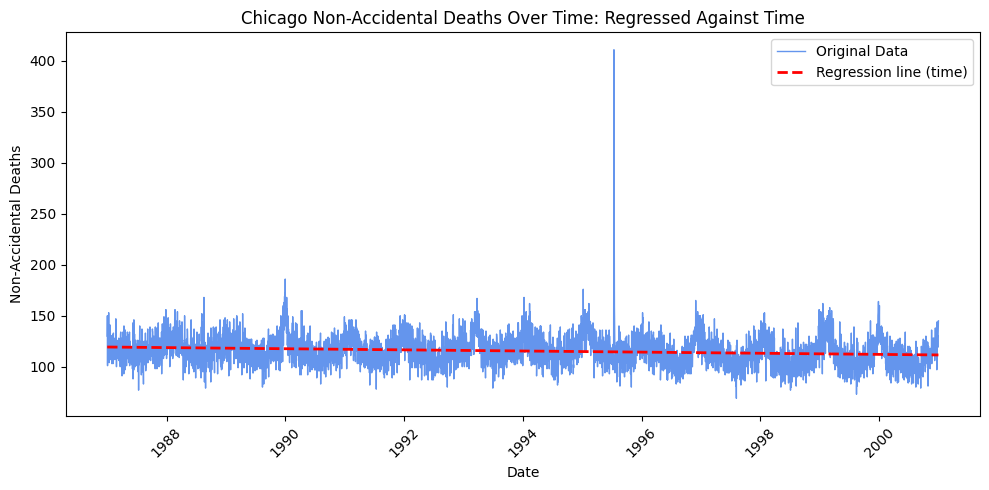

In [67]:
# Linearly regress the number of deaths against time and report the coefficients for the fitted model
# deaths = b_0 + b_1 * time
X = sm.add_constant(chicago_dat['time'])
y = chicago_dat['death']
model = sm.OLS(y, X).fit()
# print(model.summary())
int_time = model.params[0]
coef_time = model.params[1]
AIC_time = model.aic
print(f'Intercept: {int_time:.3f}, time coefficient: {coef_time:.3f}, AIC: {AIC_time:.3f}')
# Add the regression line to your plot
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat["Date"], chicago_dat["death"], linewidth=1, color = 'cornflowerblue', label='Original Data')
# deaths = b_0 + b_1 * time
reg_line = int_time + coef_time*chicago_dat['time']
plt.plot(chicago_dat["Date"], reg_line, linewidth=2, linestyle='--', color = 'red', label = 'Regression line (time)')
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time: Regressed Against Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**See interpretation at end of question.**

### Regressed against temp:

Intercept: 129.957, temp coefficient: -0.290, AIC: 41669.360


/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/1417790245.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int_temp = model.params[0]
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/1417790245.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_temp = model.params[1]


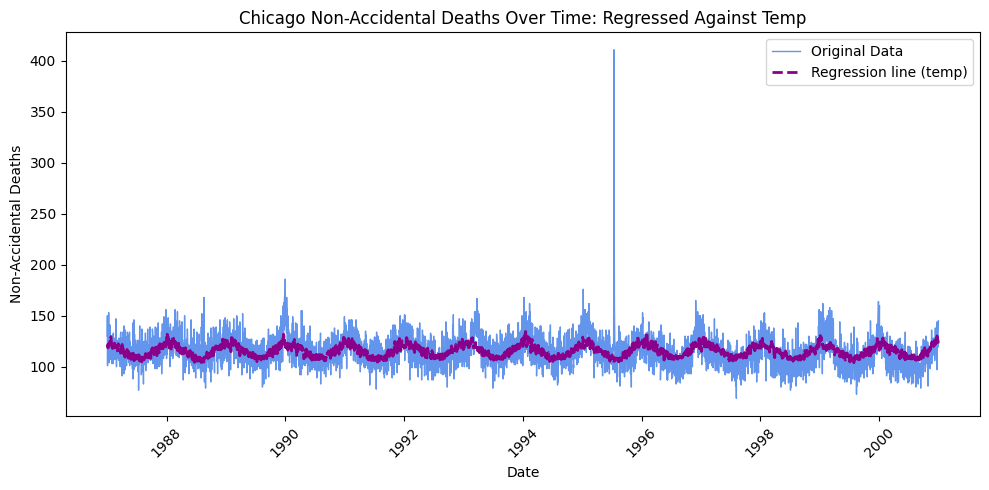

In [68]:
# linearly regress the deaths data against temperature. Once again, report the coefficients, and add the regression line to your plot.
# deaths = b_0 + b_1 * temp
X = sm.add_constant(chicago_dat['tmpd'])
y = chicago_dat['death']
model = sm.OLS(y, X).fit()
# print(model.summary())
int_temp = model.params[0]
coef_temp = model.params[1]
AIC_temp = model.aic
print(f'Intercept: {int_temp:.3f}, temp coefficient: {coef_temp:.3f}, AIC: {AIC_temp:.3f}')
# Add the regression line to your plot
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat["Date"], chicago_dat["death"], linewidth=1, color = 'cornflowerblue', label='Original Data')
# deaths = b_0 + b_1 * time
reg_line = int_temp + coef_temp*chicago_dat['tmpd']
plt.plot(chicago_dat["Date"], reg_line, linewidth=2, linestyle='--', color = 'darkmagenta', label = 'Regression line (temp)')
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time: Regressed Against Temp")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**See interpretation at end of question.**

### Regressed against temp and PM2.5 density:

Intercept: 129.957, temp coefficient: -0.371, PM2.5 coefficient: 0.215, AIC: 5712.316


/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/4122737189.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int_temp_pm25 = model.params[0]
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/4122737189.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_temp = model.params[1]
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/4122737189.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[

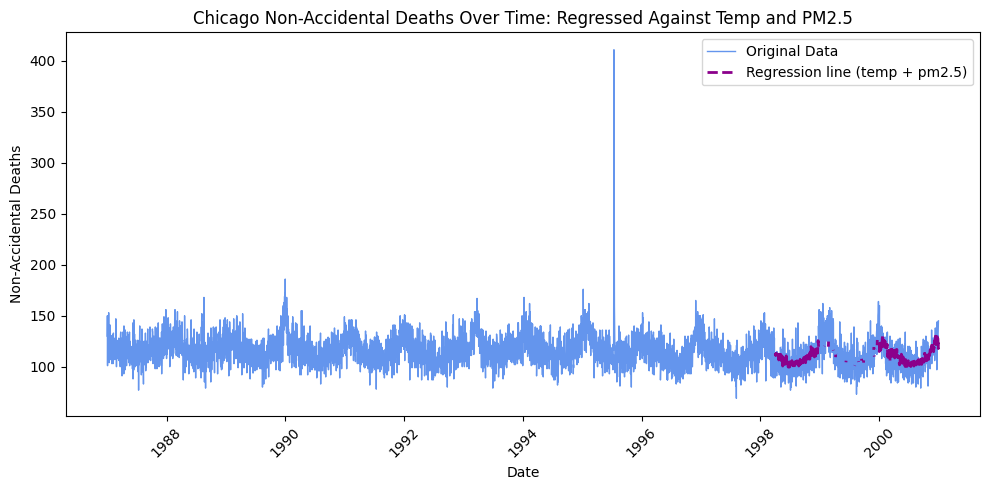

In [69]:
# Expand your previous model by regressing deaths against temperature and PM2.5 density. 
# Report the coefficients and add this regression line to your plot.
# deaths = b_0 + b_1 * temp + b_2 * pm2.5

# Had to drop rows with missing values (several for pm 2.5):
# Drop rows with missing values in the columns used for regression
regression_data = chicago_dat[['Date', 'death', 'time', 'tmpd', 'pm25median']].dropna()

# Define X and y for regression
X = sm.add_constant(regression_data[['tmpd', 'pm25median']])
y = regression_data['death']


model = sm.OLS(y, X).fit()
# print(model.summary())
int_temp_pm25 = model.params[0]
coef_temp = model.params[1]
coef_pm25 = model.params[2]
AIC_temp_pm25 =model.aic
print(f'Intercept: {int_temp:.3f}, temp coefficient: {coef_temp:.3f}, PM2.5 coefficient: {coef_pm25:.3f}, AIC: {AIC_temp_pm25:.3f}')
# Add the regression line to your plot
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat["Date"], chicago_dat["death"], linewidth=1, color = 'cornflowerblue', label='Original Data')
# deaths = b_0 + b_1 * time
reg_line = int_temp + coef_temp*chicago_dat['tmpd'] +coef_pm25*chicago_dat['pm25median']
plt.plot(chicago_dat["Date"], reg_line, linewidth=2, linestyle='--', color = 'darkmagenta', label = 'Regression line (temp + pm2.5)')
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time: Regressed Against Temp and PM2.5")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**See interpretation at end of question.**

### Redoing other models w same data as used in pm25 one above (for fair comparison via AIC):

In [70]:
# Linearly regress the number of deaths against time and report the coefficients for the fitted model
# deaths = b_0 + b_1 * time
X = sm.add_constant(regression_data['time'])
y = regression_data['death']
model = sm.OLS(y, X).fit()
# print(model.summary())
int_time = model.params[0]
coef_time = model.params[1]
AIC_time = model.aic
print(f'LIMITED DATA: Intercept: {int_time:.3f}, time coefficient: {coef_time:.3f}, AIC: {AIC_time:.3f}')

# linearly regress the deaths data against temperature. Once again, report the coefficients, and add the regression line to your plot.
# deaths = b_0 + b_1 * temp
X = sm.add_constant(regression_data['tmpd'])
y = regression_data['death']
model = sm.OLS(y, X).fit()
# print(model.summary())
int_temp = model.params[0]
coef_temp = model.params[1]
AIC_temp = model.aic
print(f'LIMITED DATA: Intercept: {int_temp:.3f}, temp coefficient: {coef_temp:.3f}, AIC: {AIC_temp:.3f}')
print(f'AIC comparison (with same dataset used in each regression): just time: {AIC_time:.3f}; just temp: {AIC_temp:.3f}; temp and pm25: {AIC_temp_pm25:.3f}.')

LIMITED DATA: Intercept: 101.651, time coefficient: 0.004, AIC: 5916.130
LIMITED DATA: Intercept: 129.209, temp coefficient: -0.369, AIC: 5727.005
AIC comparison (with same dataset used in each regression): just time: 5916.130; just temp: 5727.005; temp and pm25: 5712.316.


/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/688551614.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int_time = model.params[0]
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/688551614.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_time = model.params[1]
/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_5193/688551614.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  in

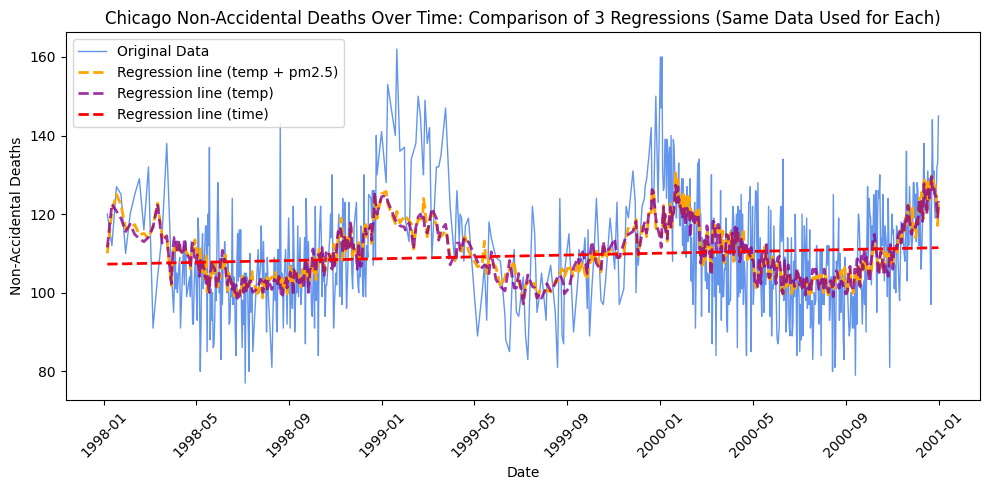

In [74]:
# Add ALL regression lines to your plot
plt.figure(figsize=(10, 5))
plt.plot(regression_data["Date"], regression_data["death"], linewidth=1, color = 'cornflowerblue', label='Original Data')
# deaths = b_0 + b_1 * time
reg_line = int_temp + coef_temp*regression_data['tmpd'] +coef_pm25*regression_data['pm25median']
plt.plot(regression_data["Date"], reg_line, linewidth=2, linestyle='--', color = 'orange', label = 'Regression line (temp + pm2.5)')
reg_line = int_temp + coef_temp*regression_data['tmpd']
plt.plot(regression_data["Date"], reg_line, linewidth=2, linestyle='--', color = 'darkmagenta', label = 'Regression line (temp)', alpha=0.8)
reg_line = int_time + coef_time*regression_data['time']
plt.plot(regression_data["Date"], reg_line, linewidth=2, linestyle='--', color = 'red', label = 'Regression line (time)')
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Chicago Non-Accidental Deaths Over Time: Comparison of 3 Regressions (Same Data Used for Each)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### Problem 3 Commentary:

- Note that although the quesiton noted that missing values here can be treated as missing at random and dropped, I completed the first two regressions first with the full dataset (because so much of the data ends up getting dropped that I thought it would be cool to see the impacts of time and temp on the full long record), and then did them again with the severely limited dataset (once rows with missing values - specifically pm2.5 - were dropped). 

**Regressed against time:**
- With FULL dataset, coefficients were: Intercept: 115.419, time coefficient: -0.002
- With COMPLETE CASE (NAs dropped) dataset, coefficients were: Intercept: 101.651, time coefficient: 0.004
- Interestingly, when we move from the full dataset to the complete case dataset (i.e., the data points that also have PM2.5 measurements late in the record), the coefficient associated with time flips sign!! (It's really small in both and might not be meaningfully different than zero, but interesting that opposite sign occurs based on how much of record you're looking at!)
- In both (full dataset and complete case dataset), the regression line appears relatively flat and does not fit the data very well (does not seem to be a great predictor of deaths).


**Regressed against temp:**
- With FULL dataset, coefficients were: Intercept: 129.957, temp coefficient: -0.290,
- With COMPLETE CASE (NAs dropped) dataset, coefficients were: Intercept: 129.209, temp coefficient: -0.369
- When we move from the full dataset to the complete case dataset, the temp coefficient has the same sign, and is slightly larger magnitude in the latter. The coefficient is negative in both, suggesting that as temperature increases, deaths go down (or conversely - as temperature DECREASES, deaths go up - which seems like a slightly more intuitive framing to me, as there could be a large number of deaths in Chicago related to folks being out in the cold during the winter).
- It is apparent, visually, in both the full dataset and complete case dataset visuals, that the trend in deaths associated with temperature is MUCH more apparent than the trend over time (i.e., regression line aligns with the data much more closely).

**Regressed against temp and PM2.5 density:**
- With COMPLETE CASE (NAs dropped) dataset, coefficients were: Intercept: 129.957, temp coefficient: -0.371, PM2.5 coefficient: 0.215.
- Again, visually, the combination of temp and PM2.5 density result in a regression line that seems to align with the data relatively well (similar to the regression line with only temperature - difficult to visually tell which might be better, hence the following AIC comparison).

**AIC comparison:**
- AIC comparison for all 3 fitted models (that used the same "complete case" dataset): just time: 5916.130; just temp: 5727.005; temp and pm25: 5712.316. Lower AIC is better, so the best model according to this comparison is the one that includes both temperature and PM2.5 density. The worst AIC was the model that only included time (which is not surprising based on the visual inspection of how that regression line fit the data, as noted above). 
- **What this tells us about the relative evidence for the influence of temperature and PM2.5 density on deaths:** Since the best performing model was the one with both temperature and PM2.5 density (and since AIC penalizes for adding predictors), this suggests that the added complexity of adding the second predictor (PM2.5) resulted in a model that was better than the model that had only temperature (i.e., better than what would be expected by having an additional predictor explain "noise" in the dataset). 
- **Comparison of conclusions based on AIC vs. conclusions from regression coefficients and plots:** I would say the AIC comparison here supported what I noted in the section examinig regression coefficients and plots. E.g., the time coefficient was nearly zero, and visually that regression line did not align well with the data, thus I was not surprised when this model did the worst in terms of AIC; the temp coefficient was larger in magnitude and sign than the time coefficient, (i.e., at a very basic level appeared more distinguishable from zero), and visually the regression line that included temp was much better than the one only including time - thus I was not surprised that the model with temp had a better AIC than the model with time. Finally, I noted above that the transition from only temp, to temp + pm2.5 as predictors, was difficult to differentiate visually or from the regression coefficients alone; as such, the AIC comparison was helpful, as it indicated that the model that included both predictors likely does a better job at representing the data we have.



## References

OpenAI. (2025). ChatGPT (April 16 version) [Large language model]. https://chatgpt.com/
